<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; "> La Poule qui chante - ANALYSE MARCHE INTERNATIONAL </h1>
</div>

## Objectif 

L'entreprise française d'agroalimentaire "La Poule qui chante" souhaite développer à l'international leur activité d'élevage et de la vente de poulets sous le label "Poulet Agriculture Biologique".

Ce projet a donc pour but d'**analyser le marché international afin d'exporter la production de notre poulet bio à l'échelle international**


**Plan :** 

   Cette étude va commencer par des nettoyage des données et par l'analyse des caractéristiques. Puis, en de ses pays en réduisant leurs dimensions à l'aide de la méthode d'ACP, on va regrouper des pays selon leurs caractéristiques similaires à l'aide de différentes méthodes de clustering (k-means, CAH), afin de déterminer les groupes de pays envisageables pour exporter le produit.

****


**A la suite du premier notebook ...**

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 0 - Importation des données </h2>
</div>

### Importation des packages

In [87]:
# Packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection


from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from itertools import combinations

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix
from sklearn import datasets

sns.set()

### Fonctions à utiliser 

In [88]:
# Fonction acp
def acp_inertie(data, cols, n_components):
    """Afficher le premier pourcentage d'inertie des composantes d'ACP
    
    """
    complet_num = data[cols] 

    A = complet_num.values
    #print(type(A))

    ## Les 2 à la fois (standardiser et normaliser les valeurs)
    A_scaled = StandardScaler().fit_transform(A)

    ## Voir la transformation (moyenne = 0 et ecart-type = 1)
    idx = ["mean", "std"]
    pd.DataFrame(A_scaled).describe().round(2).loc[idx, :]

    
    pca = PCA(n_components=n_components)

    ## Modele entrainement
    pca.fit(A_scaled)


    # variance captée par chaque nouvelle composante
    scree = (pca.explained_variance_ratio_*100).round(2)
    print(f"Variance captée par les composantes : {scree}")
    
    # cumulé 
    scree_cum = scree.cumsum().round()
    print(f"Variance cumulée captée par les composantes {scree_cum}")
    
    a_list = range(1, n_components+1)

    # Graphique cumulé
    plt.bar(a_list, scree)
    plt.plot(a_list, scree_cum,c="red",marker='o')
    plt.xlabel("rang de l'axe d'inertie")
    plt.ylabel("pourcentage d'inertie")
    plt.title("Eboulis des valeurs propres")

    plt.savefig("ptg_inertie.png")
    plt.show(block=False)

    return(scree_cum[0])
    

def acp(data, cols):
    """ Montre la variance captée par la permière composante
    """
    complet_num = data[cols] 

    A = complet_num.values
    #print(type(A))

    # Garder les noms de pays et de colonnes 
    names = complet_num.index  # Zone en index
    
    features = complet_num.columns

     ## Les 2 à la fois
    A_scaled = StandardScaler().fit_transform(A)

    ## Voir la transformation (moyenne = 0 et ecart-type = 1)
    idx = ["mean", "std"]
    pd.DataFrame(A_scaled).describe().round(2).loc[idx, :]

    n_components = len(cols)
    pca = PCA(n_components=n_components)

    ## Modele entrainement
    pca.fit(A_scaled)


    # variance captée par chaque nouvelle composante
    scree = (pca.explained_variance_ratio_*100).round(2)

    # cumulé 
    scree_cum = scree.cumsum().round()
    scree_cum2 = float(scree_cum[0])

    a_list = range(1, n_components+1)

    return(scree_cum2)


def cols_maxInertie(cols, r, data):
    """
    Trouver la combinaison des colonnes dont l'inertie est max 
    parmi l'ensemble de combinaisons de colonnes de la data
    """
    
    all_combinations = [] 
    all_combinations.extend(combinations(cols, r))

    list_inertie = []
    for i in range(0, len(all_combinations)):
        ptg_iner = acp(data, list(all_combinations[i]))
        list_inertie.append(ptg_iner)

    max_i = list_inertie.index(max(list_inertie))

    print(f"Le maximum de pourcentage d'inertie {max(list_inertie)} est atteint au {max_i}ème pour :\n {list(all_combinations[max_i])}")

    return(list(all_combinations[max_i]))
    
    

# Fonction graphique de corrélation
def correlation_graph(pca, 
                      x_y, 
                      features) : 
    """Affiche le graphe des correlations

    Positional arguments : 
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y 
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(6, 6))

    # Pour chaque composante : 
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0, 
                pca.components_[x, i],  
                pca.components_[y, i],  
                head_width=0.07,
                head_length=0.07, 
                width=0.02)

        # Les labels
        plt.text(pca.components_[x, i] + 0.02,
                pca.components_[y, i] + 0.05,
                features[i])
        
    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle 
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.savefig(f"cercle_correlation{x_y}.png")
    plt.show(block=False)
    
    
# Projection des points 
def display_factorial_planes(   X_projected, 
                                x_y, 
                                pca=None, 
                                labels = None,
                                clusters=None, 
                                alpha=1,
                                figsize=[10,8], 
                                marker="." ):

    """ Projeté les individus sur le plan factoriel désigné
    """
    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize: 
        figsize = (7,6)

    # On gère les labels
    if  labels is None : 
        labels = []
    try : 
        len(labels)
    except Exception as e : 
        raise e

    # On vérifie la variable axis 
    if not len(x_y) ==2 : 
        raise AttributeError("2 axes sont demandées")   
    if max(x_y)>= X_.shape[1] : 
        raise AttributeError("la variable axis n'est pas bonne")   

    # on définit x et y 
    x, y = x_y

    # Initialisation de la figure       
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters
 
    # Les points    
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha, 
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c, palette="viridis")

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe 
    if pca : 
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else : 
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y 
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) : 
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='10', ha='center',va='center') 

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    
    plt.savefig("projection_individu.png")
    plt.show()



### Importation du jeu de données

In [89]:
complet = pd.read_csv("complet_final.csv", decimal = ".", index_col = 0)

complet.info()
complet.head()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, Bénin to Ukraine
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culture            139 non-null    float64
 1   CH4                139 non-null    float64
 2   emploi_rural       139 non-null    float64
 3   payment            139 non-null    float64
 4   pop                139 non-null    float64
 5   dispoA_qt          139 non-null    float64
 6   export             139 non-null    float64
 7   var_stock          139 non-null    float64
 8   PIBhab             139 non-null    float64
 9   Terres_irrigation  139 non-null    float64
 10  Obesite_preval     139 non-null    float64
 11  stabPol            139 non-null    float64
 12  partSuffit_Apport  139 non-null    float64
 13  tx_dependance      139 non-null    float64
 14  var_dispo_hab      139 non-null    float64
 15  food_infla         139 non-null    float64
 16  IPP                139 

,culture,CH4,emploi_rural,payment,pop,dispoA_qt,export,var_stock,PIBhab,Terres_irrigation,Obesite_preval,stabPol,partSuffit_Apport,tx_dependance,var_dispo_hab,food_infla,IPP
name_fr,,,,,,,,,,,,,,,,,
Bénin,2.422769,0.076035,9.033011,25.857329,9.321542,14.40,0.000000,-20.0,8.020533,0.336472,9.4,0.03,120.0,50.4,2.397895,-0.047344,103.471197
Bolivie,1.872295,1.537233,7.496458,29.413175,9.323120,36.00,0.693147,103.0,9.174071,0.336472,24.4,-0.28,105.0,20.7,3.258097,3.370577,137.740000
Maroc,1.872295,1.523204,9.033011,45.751617,10.479602,20.96,0.693147,17.0,9.042040,1.648659,19.2,-0.38,142.0,60.5,3.091042,0.018993,98.210000
Moldavie,2.434239,0.526029,3.977623,32.302786,8.309107,16.14,0.000000,5.0,9.481878,2.066863,23.0,-0.31,120.0,-42.6,2.944439,8.019015,100.140000
Madagascar,0.524587,0.528449,9.033011,14.796679,10.149234,2.87,4.928553,0.0,7.420998,0.875469,3.1,-0.30,92.0,20.7,3.496508,9.300732,111.850000


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - ACP (Analyse en composantes principales) </h2>
</div>

L’Analyse en composantes principales (ACP) est une méthode de réduction de dimension et d’exploration des données. Elle a pour objectif d’étudier la variabilité entre les individus ainsi que les relations entre les variables.


La projection orthogonale de points situés dans un espace à **n>2** dimensions (caractéristiques) sur un plan à deux dimensions entraîne nécessairement une perte d’information. L’ACP cherche donc une **projection qui minimise cette perte d’information, c’est-à-dire une projection qui maximise l’inertie conservée**, correspondant à un plan le plus étalé possible. Ce plan de projection est appelé plan principal d’inertie. Ses axes orthogonaux sont appelés axes principaux d’inertie ($F_1$, $F_2$, etc.).


Ces axes sont des combinaisons linéaires des variables initiales.
Ils sont ordonnés selon la quantité de variance expliquée (l’inertie, définie comme la somme des carrés des distances des points au centre de gravité).


### Conditions d'application d'ACP

- plus de 2 variables à étudier
- variables sont toutes numériques et à la même échelle (centrées et réduites)
- abscence de valeurs manquantes
  
Ces conditions sont toutes vérifiées d'après le nettoyage des données.  


<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">1 - Composantes principales d'ACP </h2>
</div>

D’après la règle de rendu, nous devons conserver au minimum huit variables pour construire les composantes principales d'ACP. Par conséquent, nous allons examiner toutes les combinaisons possibles de variables et retenir celle qui présente la meilleure inertie en $F_1$.

In [90]:
cols = complet.columns.to_list()

# Choix de variables pour ACP
nomcols = cols_maxInertie(cols, 8, complet)  # fonction lente

Le maximum de pourcentage d'inertie 46.0 est atteint au 5725ème pour :
 ['culture', 'emploi_rural', 'payment', 'dispoA_qt', 'PIBhab', 'Obesite_preval', 'stabPol', 'partSuffit_Apport']


In [91]:
# Sélectionner de nouvelles variables avec distribution plutôt normale ou corrélés mais pas très fortes
complet_num = complet[nomcols] 
complet_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, Bénin to Ukraine
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culture            139 non-null    float64
 1   emploi_rural       139 non-null    float64
 2   payment            139 non-null    float64
 3   dispoA_qt          139 non-null    float64
 4   PIBhab             139 non-null    float64
 5   Obesite_preval     139 non-null    float64
 6   stabPol            139 non-null    float64
 7   partSuffit_Apport  139 non-null    float64
dtypes: float64(8)
memory usage: 9.8+ KB


<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">2 - Choix de variables </h2>
</div>

On cherche à déterminer le nombre de composantes qui apportent un pourcentage d’inertie adéquat. Pour cela, on peut utiliser la méthode du coude ou le critère de Kaiser.

Variance captée par les composantes : [46.18 14.89 12.13 10.11  6.57  4.8   3.4   1.92]
Variance cumulée captée par les composantes [ 46.  61.  73.  83.  90.  95.  98. 100.]


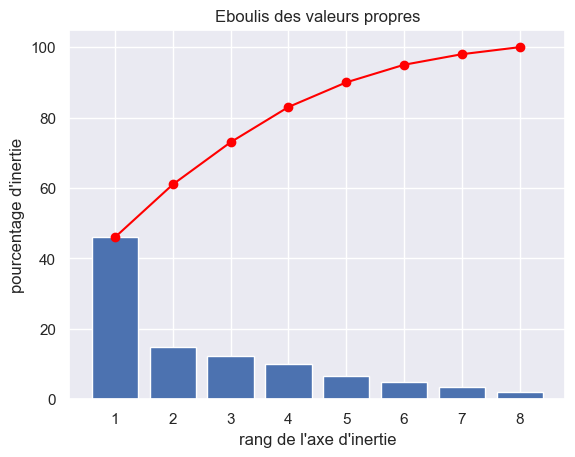

np.float64(46.0)

In [92]:
# Valeurs propres rangée par l'axe d'inertie ACP
acp_inertie(complet_num, nomcols, 8) 

### Méthode du coude

Cette méthode de choix de composante repérer l’endroit à partir duquel le pourcentage d’inertie diminue beaucoup plus lentement lorsque l’on parcourt le diagramme des éboulis de gauche à droite. 

D'après le diagramme des éboulis de valeurs propres, on peut dire qu'à partir du 4ème axe d'inertie. On observe une diminution d'accumulation de ratio d'inertie. Par conséquent, **concentrer l'analyse sur les 4 premiers axes semblent pertinents.**

### Critères de Kaiser

Si un axe explique moins d’inertie qu’une variable initiale, alors il peut être considéré comme non pertinent. Autrement dit, un axe doit expliquer au moins $100/p%$ de l’inertie totale, avec p = 8 variables dans notre cas. Par conséquent, le fait de **retenir les 3 premiers axes semble pertinent**.

In [93]:
# ACP
n_components = 8
pca = PCA(n_components=n_components)
A_scaled = StandardScaler().fit_transform(complet_num.values)
pca.fit(A_scaled)
# variance captée par chaque nouvelle composante
scree = (pca.explained_variance_ratio_*100).round(2)
print(f"Variance captée par chaque nouvelle axe : \n{scree}")

# cumulé 
scree_cum = scree.cumsum().round(2)
print(f"Variance cumulée captée par chaque nouvelle axe :\n{scree_cum}")

print(f"Les axes d'inertie qui ont moins de {100/8}% de pourcentage d'inertie ont une explicativité plus faible d'une variable initiale ! ") 
# retenir 3 axes d'inertie est un bon choix

Variance captée par chaque nouvelle axe : 
[46.18 14.89 12.13 10.11  6.57  4.8   3.4   1.92]
Variance cumulée captée par chaque nouvelle axe :
[ 46.18  61.07  73.2   83.31  89.88  94.68  98.08 100.  ]
Les axes d'inertie qui ont moins de 12.5% de pourcentage d'inertie ont une explicativité plus faible d'une variable initiale ! 


**Conclusion :** On choisira 4 premiers axes d'inertie en respectant la méthode du coude et le score de silhouette.

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">3 -  Liaison entre variables et variation des individus </h2>
</div>

In [117]:
# Matrice des variables numériques
A = complet_num.values
print(type(A))

# centrée réduite
A_scaled = StandardScaler().fit_transform(A)

# Choix final de composante
n_components = 4
pca = PCA(n_components=n_components)

## Modele entrainement
pca.fit(A_scaled)

pcs = pca.components_
# pcs (plan composants)

a_list = range(1, n_components+1)

<class 'numpy.ndarray'>


In [118]:
# nom des pays
names = complet.index  # Zone en index
print(names)

# nom des variables
features = complet_num.columns
print(features)

Index(['Bénin', 'Bolivie', 'Maroc', 'Moldavie', 'Madagascar', 'Soudan', 'Iran',
       'Koweït', 'Nouvelle-Zélande', 'Etats-Unis',
       ...
       'Uganda', 'Uruguay', 'Saint-Vincent-et-les-Grenadines', 'Bangladesh',
       'Chine', 'Gabon', 'Liban', 'Pakistan', 'Roumanie', 'Ukraine'],
      dtype='object', name='name_fr', length=139)
Index(['culture', 'emploi_rural', 'payment', 'dispoA_qt', 'PIBhab',
       'Obesite_preval', 'stabPol', 'partSuffit_Apport'],
      dtype='object')


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">1 - Axes d'inertie et ses caractéristiques</h3>
</div>

On trace maintenant l'axe d'inertie et ses composantes pour étudier la relation entre ces variables composantes les axes d'inertie à l'aide du cercle de corrélation.

In [119]:
# les composantes
pcs = pd.DataFrame(pcs)

# Composantes explicant les plans factoriels 
pcs.columns = features                # ajouter nom de colonnes
pcs.index = [f"F{i}" for i in a_list] # ajouter un index

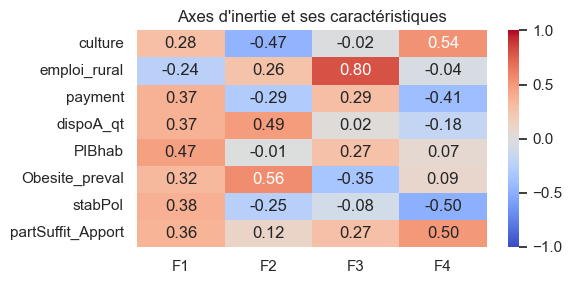

In [123]:
# représenter par visuel
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

plt.title("Axes d'inertie et ses caractéristiques")
plt.tight_layout()
plt.savefig("composant_inertie.png")
plt.show()

In [121]:
# Les axes d'inertie F1 et F2
f1 = pca.components_[0]
print("F1 : ", f1)

f2 = pca.components_[1]
print("F2 : ", f2)

F1 :  [ 0.28397913 -0.23872873  0.36777933  0.36812949  0.46568881  0.32402259
  0.37553656  0.35874654]
F2 :  [-0.47154101  0.26400004 -0.29346329  0.48673387 -0.00502599  0.55557205
 -0.25013934  0.11690694]


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">2 - Cercle de corrélation</h3>
</div>

Le cercle de corrélation montre la **relation entre les variables originales, leur lien avec les axes** de l’ACP et quelles variables expliquent chaque composante.

Chaque flèche représente une variable et les axes sont les composantes principales ($F_1$, $F_2$, etc.). Le cercle est de rayon 1. Plus la projection orthogonale sur un axe d'une flèche est longue plus la variable est bien représenté par cet axe. Et plus l'angle entre la flèche et l'axe est petit plus ils sont corrélés s'ils sont opposés alors ils sont anticorrélés.

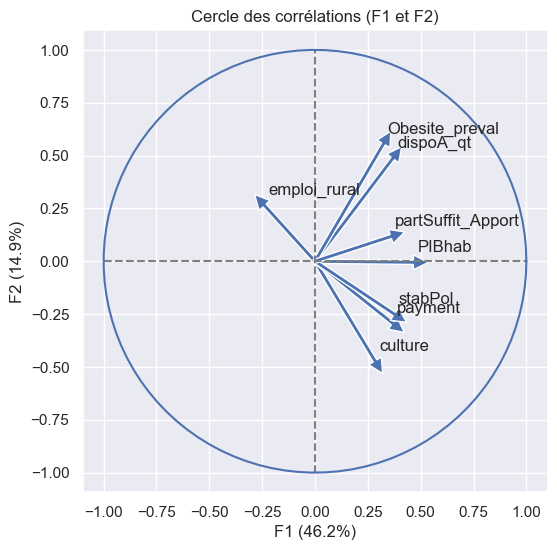

In [57]:
# 1er plan factoriel
x_y = (0,1)
# Application de la fonction
correlation_graph(pca, x_y, features)


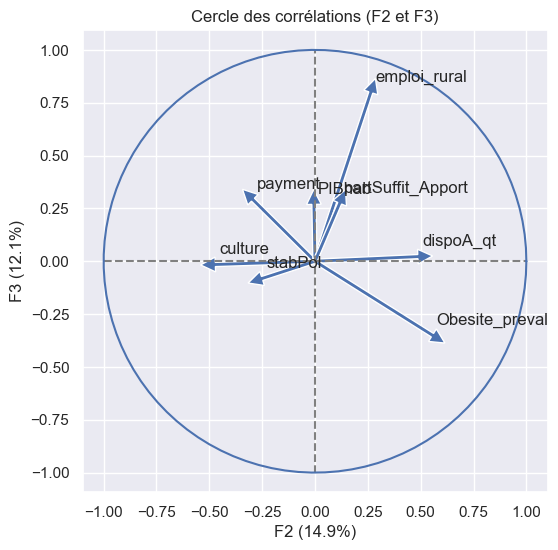

In [58]:
# 2ème plan factoriel
x_y = (1,2)
# Application de la fonction
correlation_graph(pca, x_y, features)

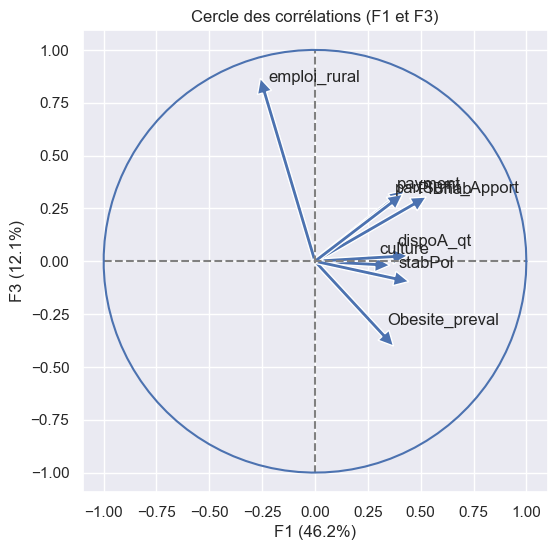

In [59]:
x_y = (2,3)

# Application de la fonction
correlation_graph(pca, x_y, features)

D’après le cercle des corrélations sur le premier plan factoriel, le premier axe $F_1$ explique $46,2\%$ de la variabilité totale des données. Il est principalement défini par une combinaison linéaire des variables **payment, dispoA_qt, PIBhab, stabPol et partSuffit_Apport**, qui contribuent chacune à hauteur d’environ $40\%$.
De l'autre côté, les variables **Obesite_preval, dispoA_qt et culture** sont fortement corrélées au deuxième axe d’inertie $F_2$, lequel explique environ $50\%$ de l’inertie associée à ce plan.

On peut en déduire que :
- l’axe $F_1$ synthétise principalement les dimensions liées à la **sécurité politique, économique et alimentaire**,
- l’axe $F_2$ reflète davantage l’aspect **socio-culturel**, en particulier le niveau de culture et les comportements associés.

Au total, le premier plan factoriel a une inertie totale de $61,1\%$.

Puis, l'**emploi rural** est la variable qui est très bien représentée par le $F_3$.

<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">3 - Projection des individus</h3>
</div>

On peut ensuite observer à travers la projection des individus sur le premier plan d'inertie, la relation entre les individus.

In [60]:
A_proj = pca.transform(A_scaled)

C:\Users\cairo\AppData\Local\Temp\ipykernel_6528\167296764.py:210: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c, palette="viridis")


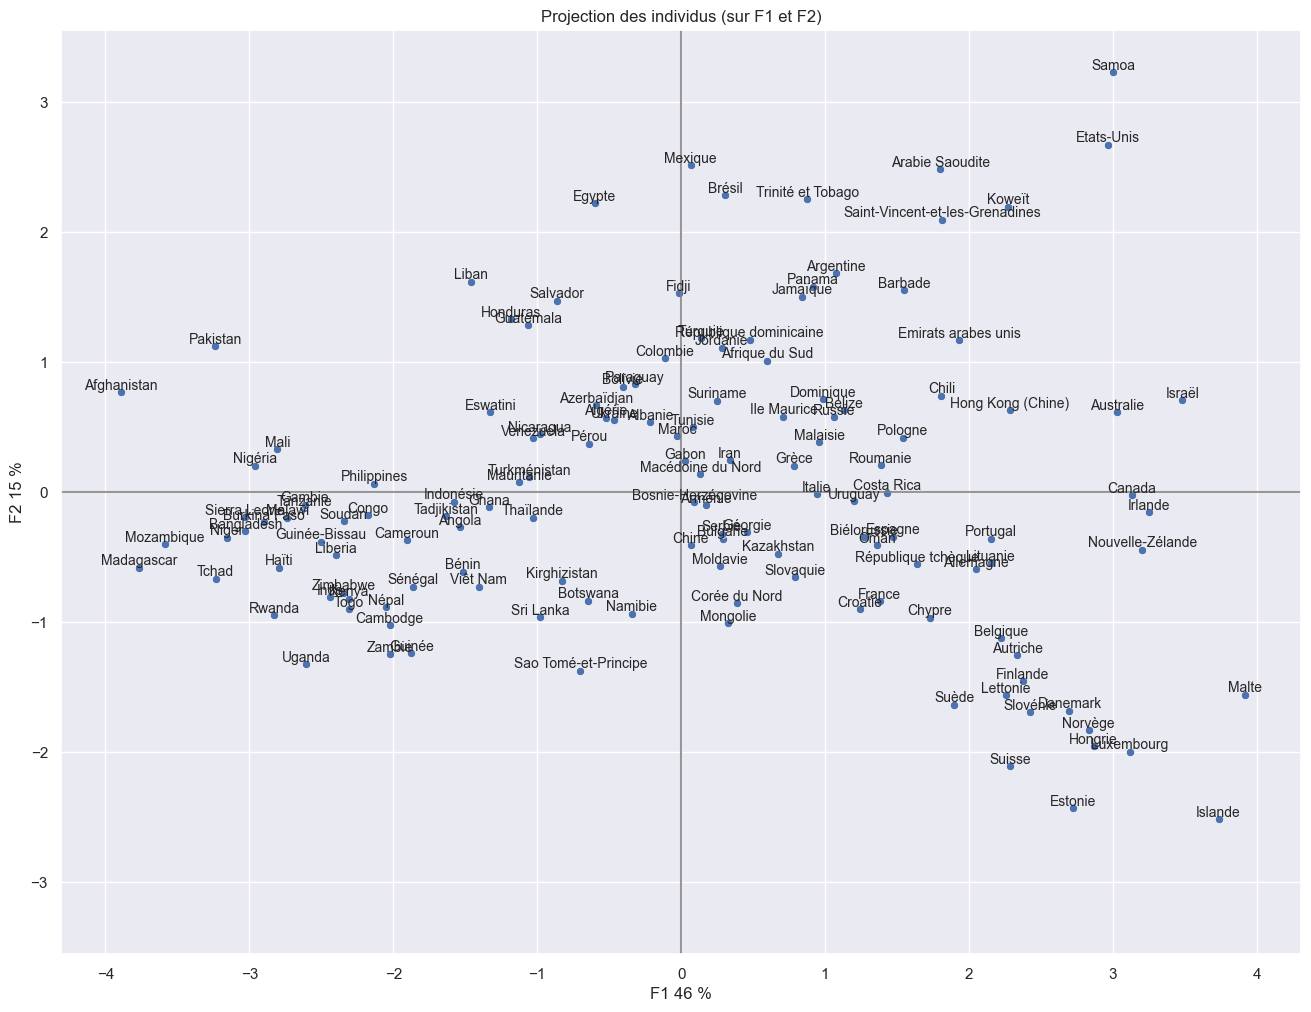

In [61]:
x_y = [0,1]
display_factorial_planes(A_proj, x_y, pca, labels=names, figsize=(16,12), marker="o", alpha = 0.5)

C:\Users\cairo\AppData\Local\Temp\ipykernel_6528\167296764.py:210: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c, palette="viridis")


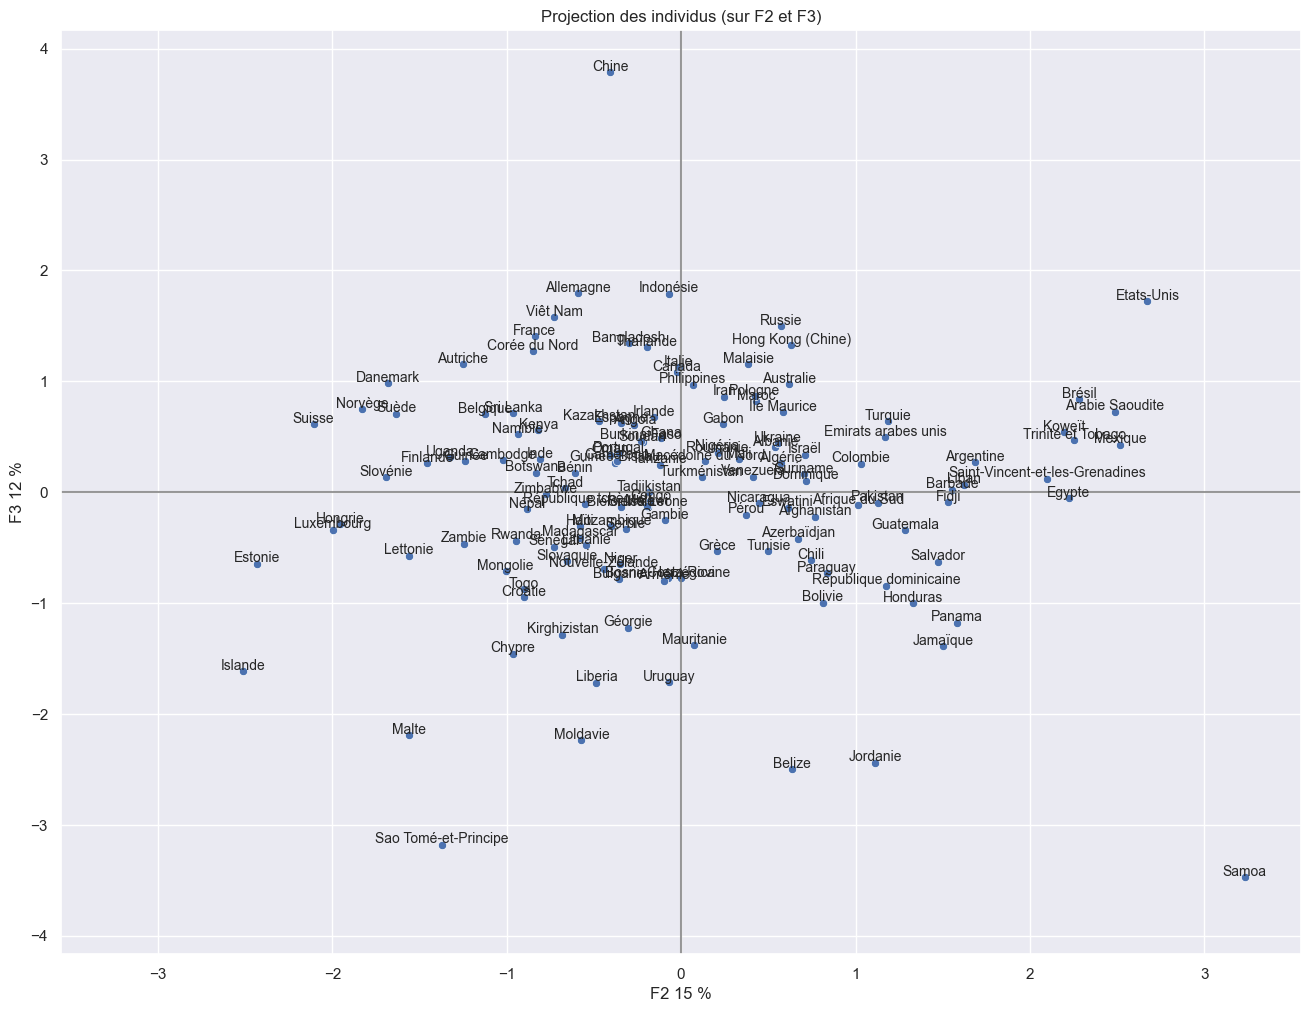

In [62]:
x_y = [1,2]
display_factorial_planes(A_proj, x_y, pca, labels=names, figsize=(16,12), marker="o", alpha = 0.5)

Les distances entre les pays sur un même plan de projection reflètent leurs similarités (ou dissimilarités) au regard de ces caractéristiques.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> Etape 2 - Partitionner les données </h2>
</div>

Une fois les composantes principales ont été trouvés. On cherche ensuite à classifier les pays qui se ressemblent à l'aide des méthodes de clustering comme :
- CAH (Classification Ascendante Hiérarchique)
- K-means

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">1 - CAH (Classification Ascendante Hiéarchique) </h2>
</div>

La Classification Ascendante Hiérarchique (CAH) est une méthode de clustering non supervisé qui **regroupe les observations en fonction de leur similarité**. La similarité traduit par la distance. Et la distance entre individus est mesurée par différentes méthodes :
- single (distance minimale)
- complete (distance maximale)	
- average (distance moyenne)
- ward (minimise la variance intra-cluster)

On commence avec chaque observation seule et on fusionne progressivement les observations les plus proches jusqu’à obtenir un seul cluster. 


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">1 - Groupes de CAH</h3>
</div>

In [64]:
# On essaie de minimiser la variance intra-cluster
M = linkage(A_scaled, method = "ward")

### Choix de clusters k avec dendrogramme

Le dendrogramme est un graphique visuel représentant la méthode de CAH. On peut observer la distance horizontale et verticale présentent sur le dendrogramme pour sélectionner le nombre de clusters k. 

L'axes verticaux sont la distance de fusion et l'axes horizontaux représente les clusters. **Plus un saut vertical est grand, plus les clusters fusionnés sont très différents**.

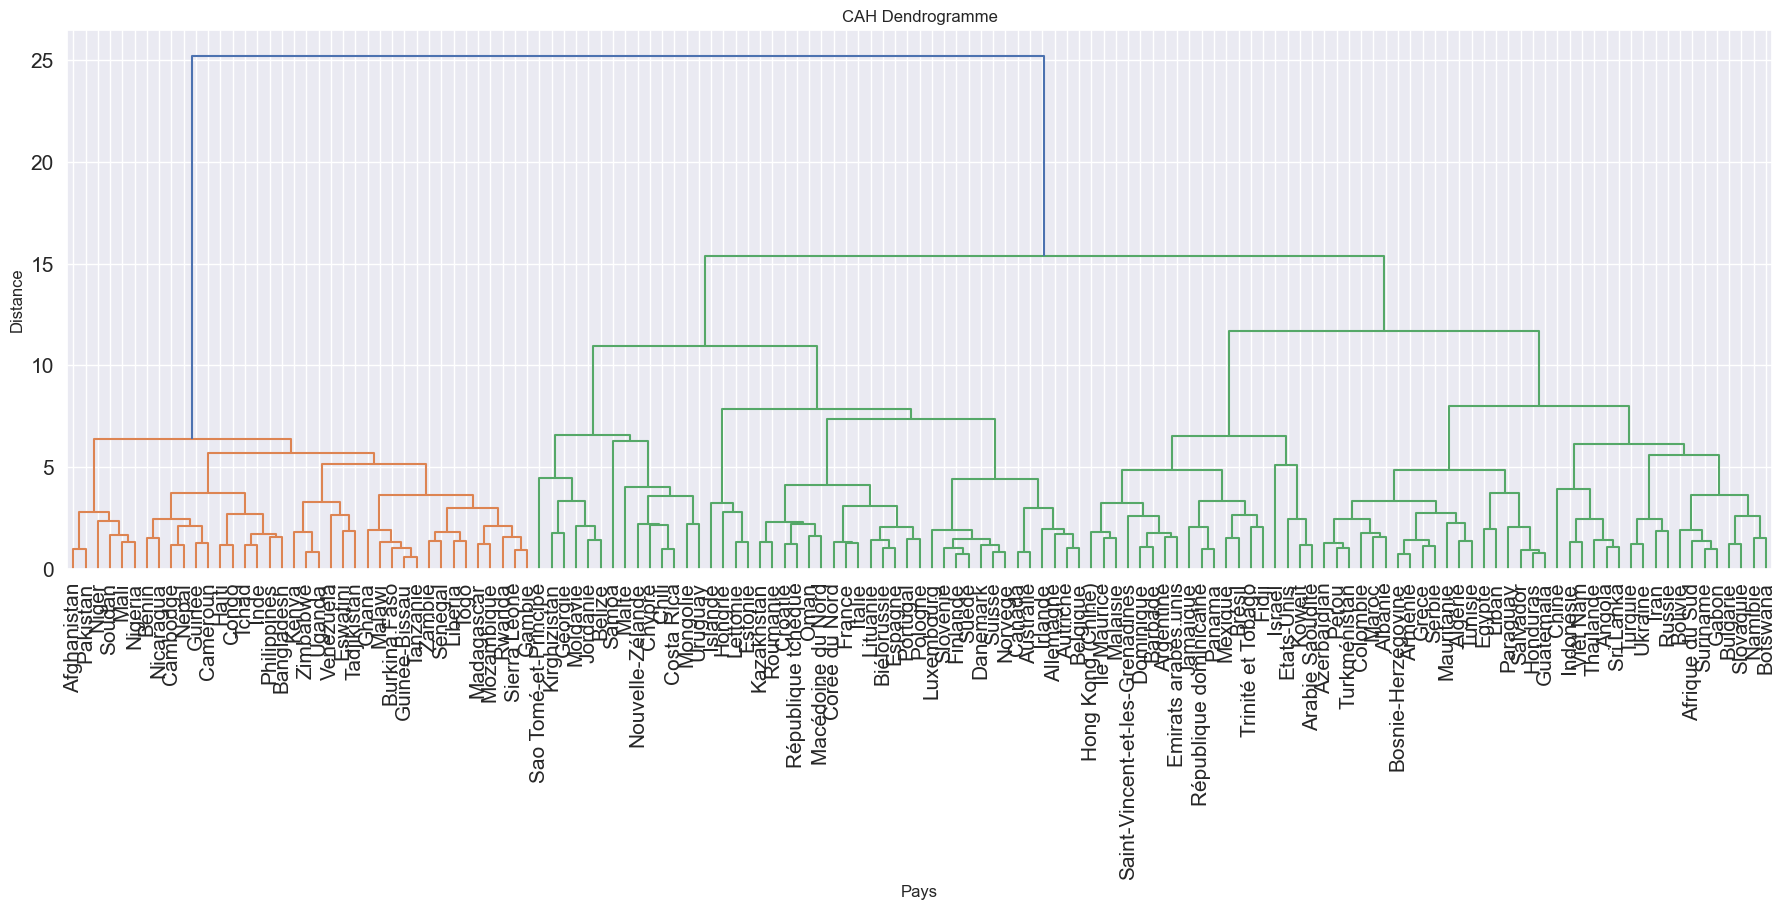

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(22,7))

_ = dendrogram(M, ax=ax, labels=names)

plt.title("CAH Dendrogramme")
ax.set_ylabel("Distance")
ax.set_xlabel("Pays")
ax.tick_params(axis='x', which='major', labelsize=15)
ax.tick_params(axis='y', which='major', labelsize=15)

plt.savefig("dendrogram.png", bbox_inches="tight")
plt.show()

On peut observer 3 groupes de pays différents.

### Projection des individus selon CAH

In [66]:
k = 3
clusters = fcluster(M, k, criterion='maxclust') # clusters de dendrogramme

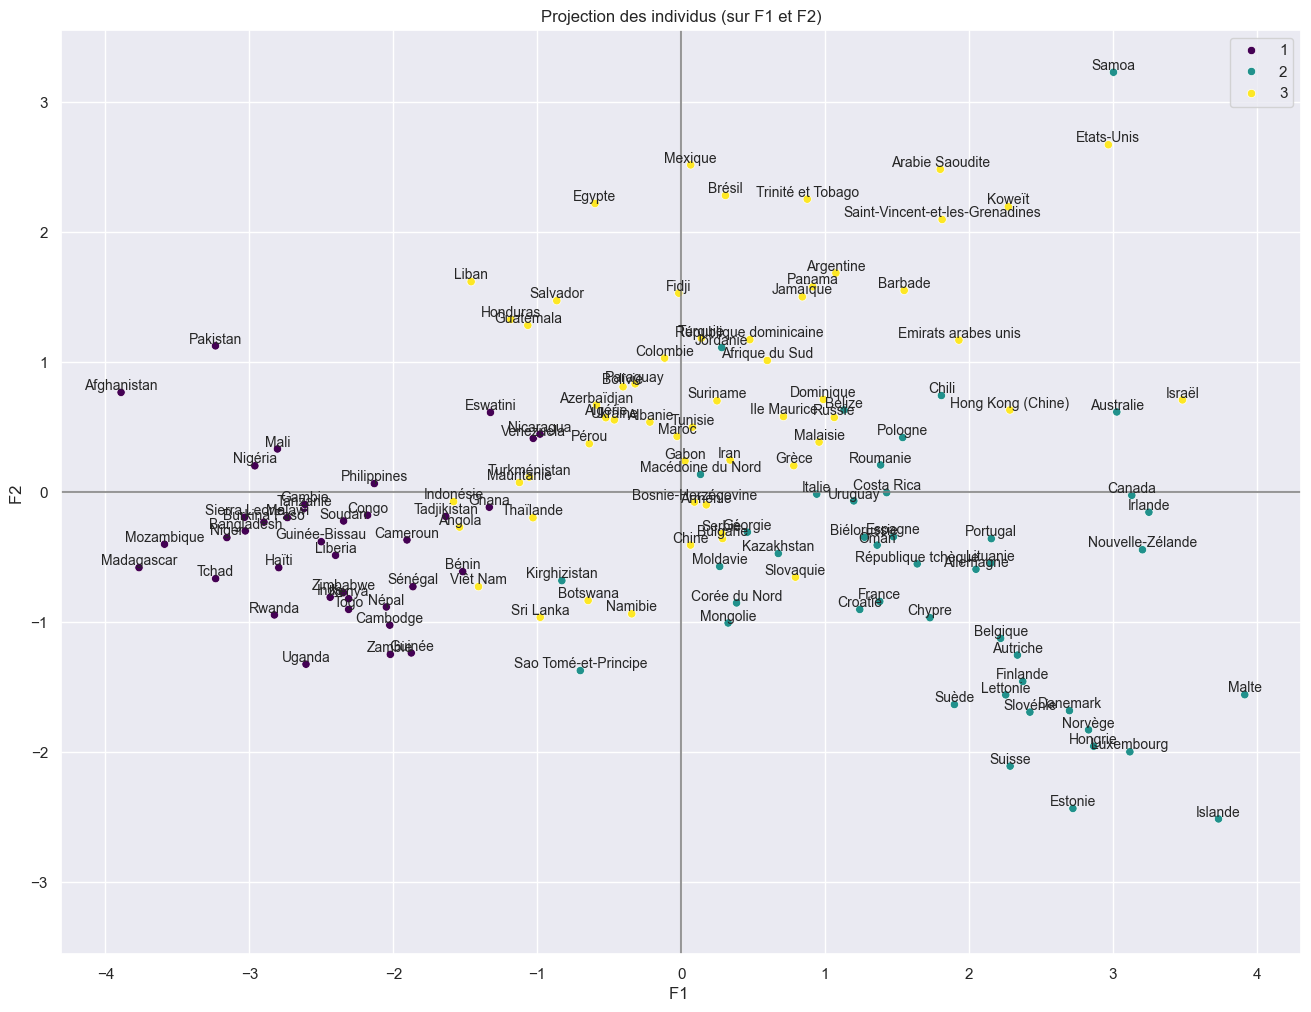

In [67]:
# Projection des pays avec clusters
x_y = (0,1)
display_factorial_planes(A_proj, x_y, clusters = clusters, labels = names,  figsize=(16,12), alpha = 0.5)

<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">2 - Caractéristiques des groupes</h3>
</div>

Afin d'étudier les caractéristiques de chaque groupe, on doit transformer les variables à des variables initiales selon la fonction exponentielle.

In [72]:
complet_cluster = complet_num.copy()

# transformer en valeur originale avec exponentielle pour les colonnes ['emploi_rural', 'PIBhab']
cols = ['emploi_rural', 'PIBhab']
for col in cols:
    complet_cluster.loc[:, col] = np.expm1(complet_cluster[col])

complet_cluster.loc[:, 'cluster'] = clusters

print("Les groupes possèdent des caractéristiques suivants :")
complet_cluster.groupby('cluster').mean()

Les groupes possèdent des caractéristiques suivants :


,culture,emploi_rural,payment,dispoA_qt,PIBhab,Obesite_preval,stabPol,partSuffit_Apport
cluster,,,,,,,,
1,1.261174,8243.344657,30.005360,5.472368,4514.631121,9.934249,-0.775789,109.973684
2,2.796473,1895.642420,64.553574,23.200000,42347.868889,23.357778,0.610667,130.822222
3,1.544341,13668.579975,41.327862,26.680357,23203.133929,23.639312,-0.176989,126.214286


In [73]:
complet_cluster['cluster'].value_counts() #Le nombre de pays par groupe est suffisant et équitable

cluster
3    56
2    45
1    38
Name: count, dtype: int64

### Exemples par groupe

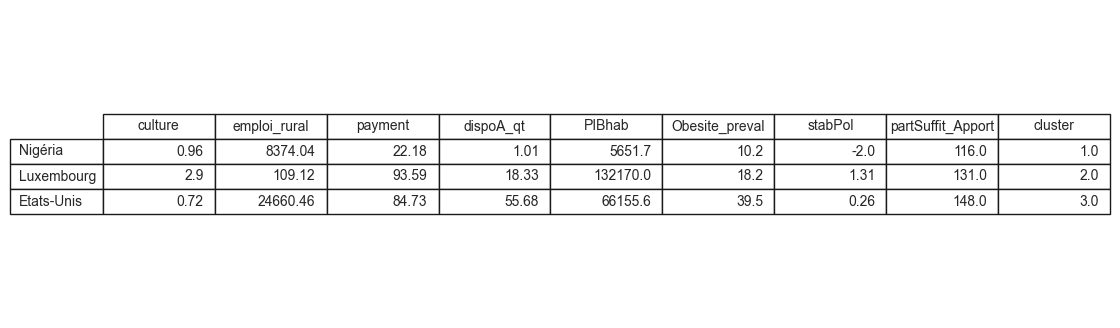

In [83]:
cluster_1 = complet_cluster.index.get_loc("Nigéria")
cluster_2 = complet_cluster.index.get_loc("Luxembourg")
cluster_3 = complet_cluster.index.get_loc("Etats-Unis")

exemple = complet_cluster.iloc[[cluster_1, cluster_2, cluster_3]]

# exemple par groupes
tab = exemple.round(2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=tab.values,
    colLabels=tab.columns,
    rowLabels=tab.index,
    loc='center'
)

table.scale(1.3, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.savefig("ex_cah.png", dpi=300, bbox_inches='tight')
plt.show()

<div style="background-color: RGB(51,100,182);" >
<h2 style="margin: auto; padding: 16px; color:#fff; ">2 - K-means </h2>
</div>

K-means est une méthode de **classification non supervisée** qui vise à regrouper des observations en **k groupes homogènes**, 
en minimisant la distance entre les pays d’un même groupe. 

C'est une méthode simple et rapide, malgré ses inconvénients sont nombreux tels que le nombre de clusters k doit être fixé à l’avance, qu'elle est sensible à l’initialisation et aux valeurs aberrantes et suppose des clusters de forme plutôt sphérique. 

On peut trouver un nombre de clusters adéquat grâce à l'indicateur d'**inertie intraclasse (dispersion des individus au sein d’un même groupe)** et le **score de silhouette**.

<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">1 - Groupes de K-means</h3>
</div>

### Choix de clusters k

- Indice d’inertie intra-classe : plus la dispersion des individus au sein d’un même groupe est faible, **plus l’inertie intra-classe est faible, et meilleure est la qualité du regroupement**.

- Score de silhouette : ce score varie entre –1 et 1. **Plus la classification est cohérente, plus la valeur du score est élevée (proche de 1)**.

In [110]:
pca = PCA(n_components=4) 
A_pca = pca.fit_transform(A_scaled)
print(f"Variance captée est de : {round(pca.explained_variance_ratio_.sum()*100,2)}")


# indice silouette (varie entre -1 et 1 = meilleur classification)
inertia_list = []
score_list = []
k_list = range(2, 20)  

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(A_pca)
    
    # Ajouter l'inertie à la liste
    inertia_list.append(kmeans.inertia_)
    
    # Prédire les labels
    labels = kmeans.predict(A_pca)
    
    # Calculer et ajouter le score silhouette
    score_list.append(silhouette_score(A_pca, labels))
    
    #print(f"k={k}, Indice de silhouette : {silhouette_score(A_pca, labels):.2f} et d'inertie {kmeans.inertia_:.2f}")


Variance captée est de : 83.32


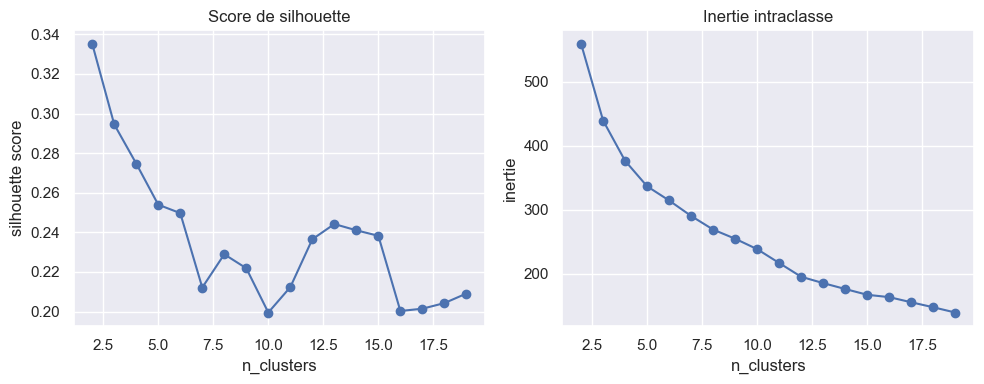

In [111]:
# Visualisation des indices de choix de clusters
fig, ax = plt.subplots(1,2,figsize=(10,4))

# Graphique silhouette
ax[0].plot(k_list, score_list, marker="o")
ax[0].set_xlabel("n_clusters")
ax[0].set_ylabel("silhouette score")
ax[0].set_title("Score de silhouette")

# Graphique inertie
ax[1].plot(k_list, inertia_list, marker="o")
ax[1].set_xlabel("n_clusters")
ax[1].set_ylabel("inertie")
ax[1].set_title("Inertie intraclasse")

plt.tight_layout()
plt.savefig("choix_nclusters_kmeans.png")
plt.show()


# Avec l'indice de silouette il est mieux de prendre k=2 pour le groupement

L’indice de silhouette est maximal pour un nombre de clusters égal à **k=2**, puis présente une valeur également élevée pour **k=3**.

Par ailleurs, l’inertie intra-classe diminue systématiquement lorsque le nombre de clusters augmente. On cherche alors un point de rupture de la courbe, indiquant à partir de quel nombre de clusters l’amélioration devient marginale. Ce point de rupture est observé pour un nombre de clusters proche de **k=3**.

### Projection des individus selon Kmeans

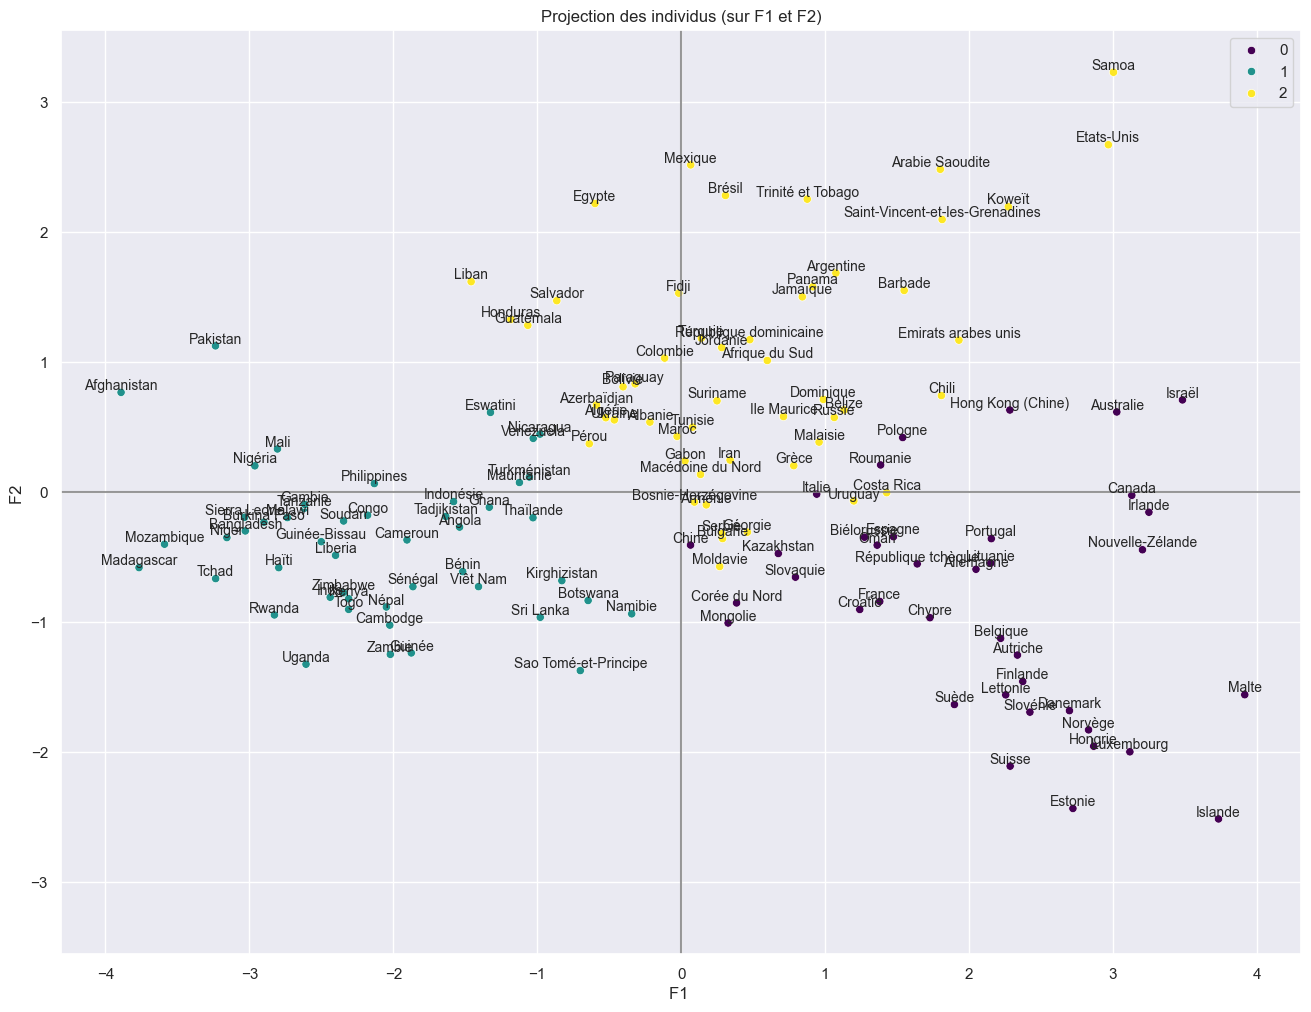

In [112]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(A_pca) 
clusters = kmeans.predict(A_pca)

x_y = (0,1)
display_factorial_planes(A_proj, x_y, clusters = clusters, labels = names,  figsize=(16,12), alpha = 0.5)


<div style="background-color: RGB(51,130,182);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">2 - Caractéristiques des groupes</h3>
</div>

In [113]:
complet_cluster = complet_num.copy()

# transformer en valeur originale avec exponentielle pour les colonnes ['emploi_rural', 'PIBhab']
cols = ['emploi_rural', 'PIBhab']
for col in cols:
    complet_cluster.loc[:, col] = np.expm1(complet_cluster[col])

complet_cluster.loc[:, 'cluster'] = clusters
complet_cluster.groupby('cluster').mean()

,culture,emploi_rural,payment,dispoA_qt,PIBhab,Obesite_preval,stabPol,partSuffit_Apport
cluster,,,,,,,,
0,2.975376,10825.453919,71.733988,24.655000,51353.160526,20.528986,0.698534,134.236842
1,1.344086,9593.403567,31.711804,6.038980,6074.095563,10.704111,-0.618367,111.673469
2,1.563933,5433.605015,39.994323,29.100962,21683.361538,27.842308,-0.156840,126.173077


### Exemples de groupe

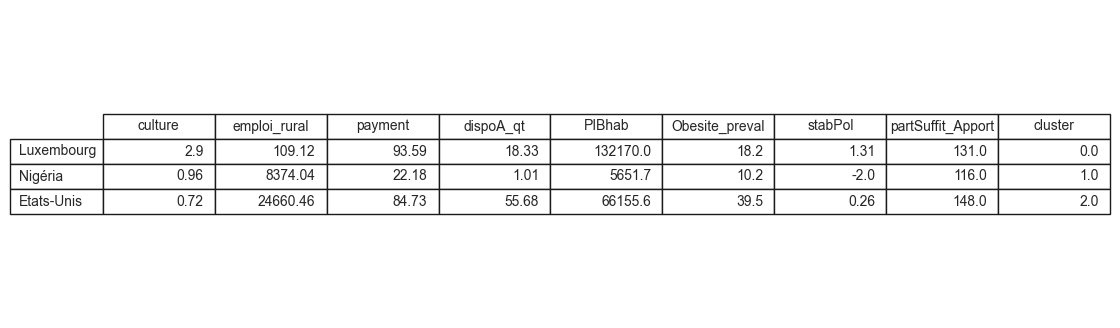

In [114]:
cluster_0 = complet_cluster.index.get_loc("Luxembourg")
cluster_1 = complet_cluster.index.get_loc("Nigéria")
cluster_2 = complet_cluster.index.get_loc("Etats-Unis")

exemple = complet_cluster.iloc[[cluster_0, cluster_1, cluster_2]]

# exemple par groupes
tab = exemple.round(2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=tab.values,
    colLabels=tab.columns,
    rowLabels=tab.index,
    loc='center'
)

table.scale(1.3, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.savefig("ex_kmeans.png", dpi=300, bbox_inches='tight')
plt.show()

# Luxembourg => forte PIBhab, dispoA moyennement fort, niveau de culture élevé, technique de paiment d'achat plus moderne
# Nigéria => disponibilité alimentaire faible, stabilité politique rare, moins d'utilisation de paiement de technique avancé
# Etats-Unis => un emploi rural important, disponibilité alimentaire importante, PIB par habitant important, une prévalence d'obésité plsu important.


In [115]:
# Nombre de pays par clusters 
complet_cluster['cluster'].value_counts()
#Le nombre de pays est plutôt suffisant sur chaque groupe et équitable

cluster
2    52
1    49
0    38
Name: count, dtype: int64

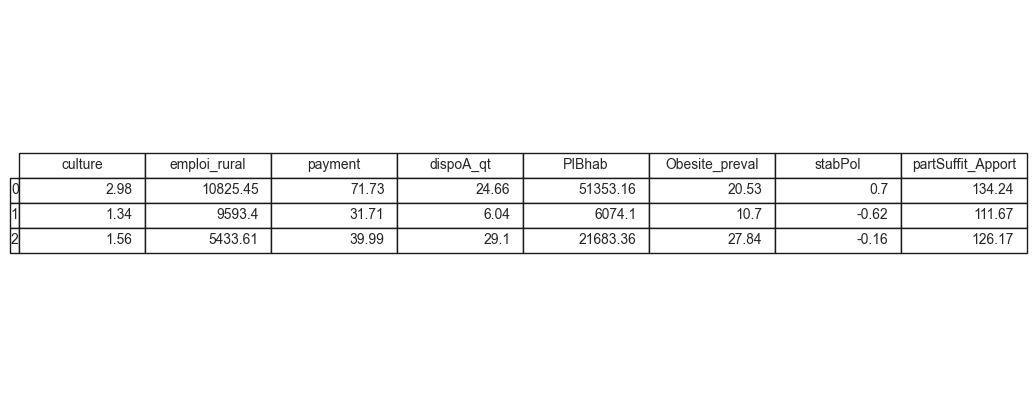

In [116]:
# Tableau de groupe
tab = complet_cluster.groupby('cluster').mean().round(2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

table = ax.table(
    cellText=tab.values,
    colLabels=tab.columns,
    rowLabels=tab.index,
    loc='center'
)

table.scale(1.3, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.savefig("groupes_kmeans.png", dpi=300, bbox_inches='tight')
plt.show()

### Conclusion 

Afin de mieux commercialiser notre poulet, nous privilégions les pays disposant de ressources suffisantes, de revenus élevés et de conditions économiques favorables, tout en accordant une importance particulière à la stabilité politique.

Ainsi, le groupe 1 est écarté dans un premier temps en raison de sa faible stabilité politique moyenne (stabPol = − 0,62). Nous ciblons ensuite des pays où le revenu par habitant est élevé. Dans cette optique, le marché du **groupe 0**, caractérisé par un PIB par habitant moyen de 51 353,3, apparaît comme particulièrement propice à l’expansion du produit « Poulet Bio ».

# Fin de notebook